# Exploratory Data Analysis



In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "train.csv" # Changed from "" to "train.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "rohitsahoo/sales-forecasting",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

Using Colab cache for faster access to the 'sales-forecasting' dataset.
First 5 records:    Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United S

In [ ]:
df.shape

(9800, 18)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [ ]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
df.drop(columns=['Postal Code','Row ID','Order ID','Customer ID','Customer Name'],inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df.drop_duplicates(inplace=True)

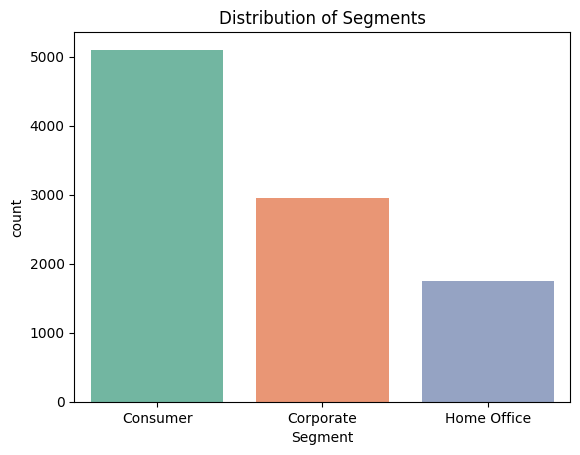

In [ ]:
sns.countplot(data=df, x='Segment', palette='Set2')
plt.title("Distribution of Segments")
plt.show()

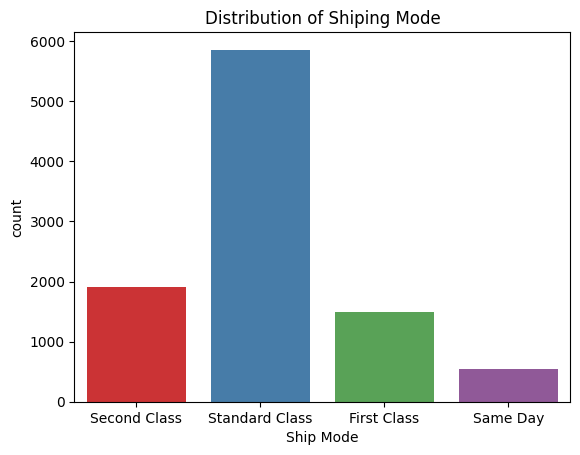

In [ ]:
sns.countplot(data=df, x='Ship Mode', palette='Set1')
plt.title("Distribution of Shiping Mode")
plt.show()

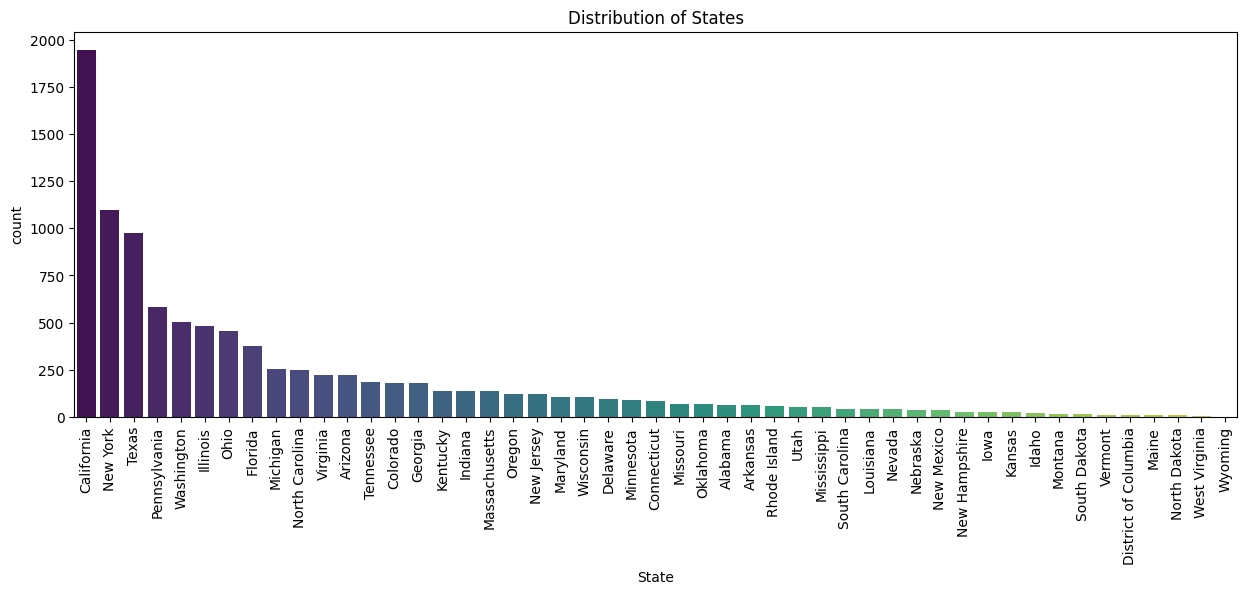

In [ ]:
plt.figure(figsize = (15,5))
order= df['State'].value_counts().index
sns.countplot(data=df, x='State',order=order,palette='viridis')
plt.title("Distribution of States")
plt.xticks(rotation=90)
plt.show()


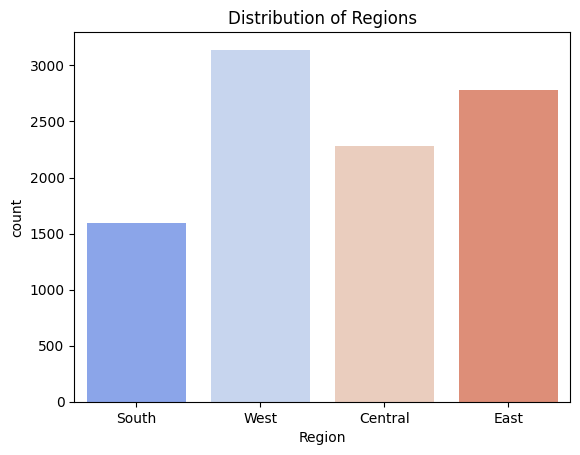

In [ ]:
sns.countplot(data=df, x='Region', palette='coolwarm')
plt.title("Distribution of Regions");

In [ ]:
df['Category'].nunique()


3

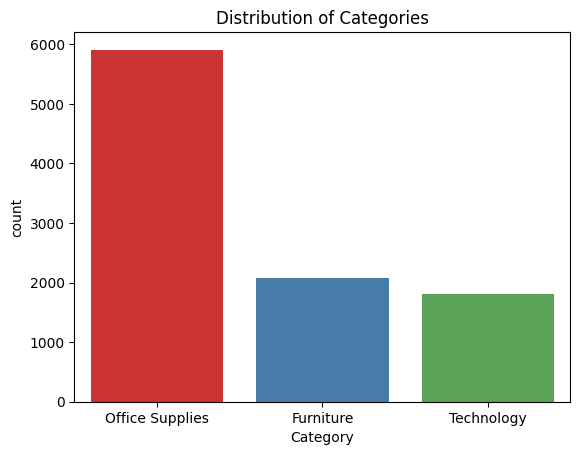

In [ ]:
sns.countplot(data=df, x='Category', palette='Set1', order= df['Category'].value_counts().index)
plt.title("Distribution of Categories");

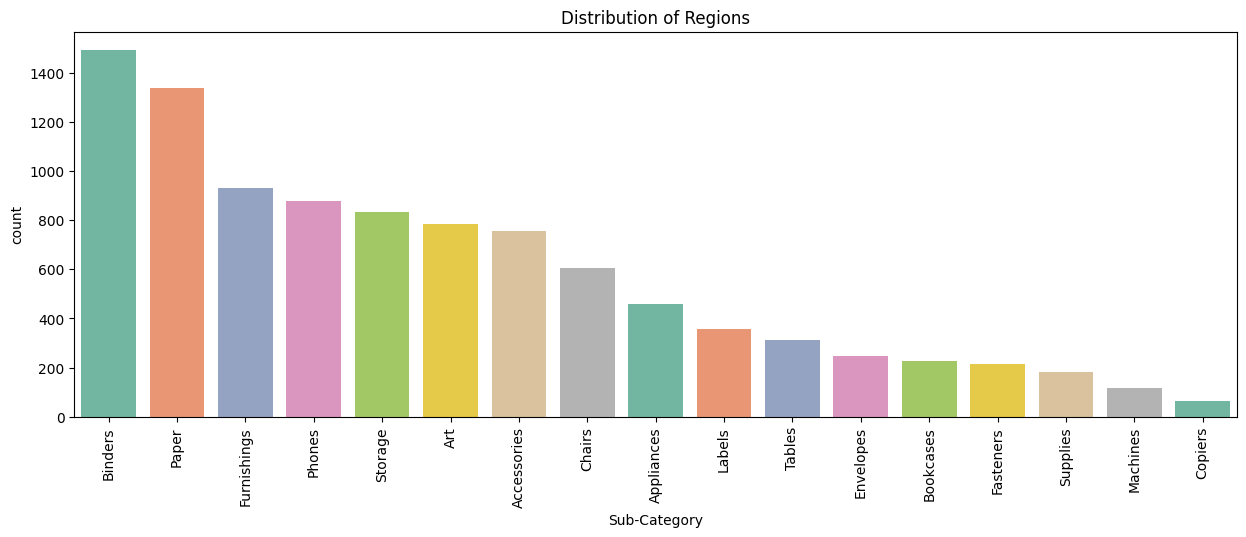

In [ ]:
plt.figure(figsize = (15,5))
sns.countplot(data=df, x='Sub-Category', palette='Set2',order= df['Sub-Category'].value_counts().index)
plt.xticks(rotation=90)
plt.title("Distribution of Regions");

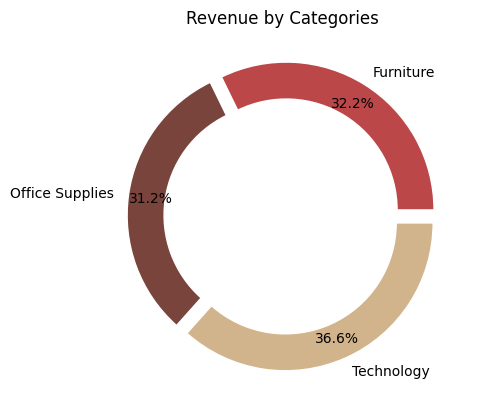

In [ ]:
cate_rev = df.groupby('Category')['Sales'].sum()
plt.pie(cate_rev, labels=cate_rev.index,autopct = '%1.1f%%',
        colors = ['#bc4749', '#79443B', '#D2B48C'],
        explode= (0.05, 0.05, 0.05), pctdistance=0.85,
        wedgeprops=dict(width=.25, edgecolor='w'),radius=1)
plt.title('Revenue by Categories');

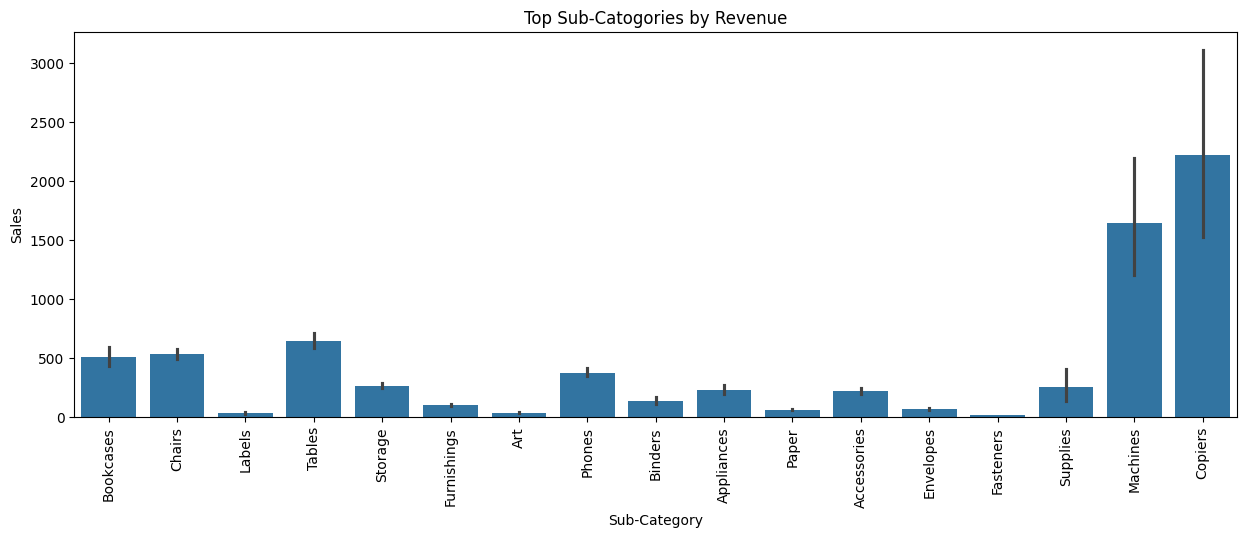

In [ ]:
plt.figure(figsize=(15,5))
sns.barplot(x=df['Sub-Category'],y=df['Sales'])
plt.title('Top Sub-Catogories by Revenue')
plt.xticks(rotation=90);

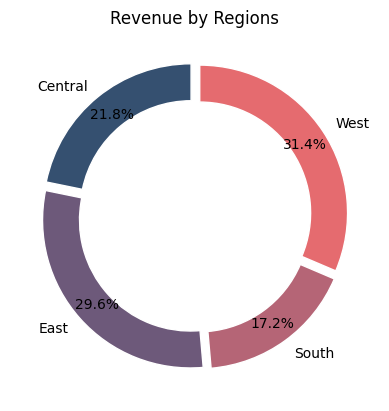

In [ ]:
reg_rev = df.groupby('Region')['Sales'].sum()
plt.pie(reg_rev, labels=reg_rev.index,autopct ='%1.1f%%',
        colors = ['#355070','#6d597a','#b56576','#e56b6f'],
        explode= (0.04, 0.04, 0.04,0.04), pctdistance=0.85,
        wedgeprops=dict(width=.25, edgecolor='w'),radius=1,startangle=90)
plt.title('Revenue by Regions');

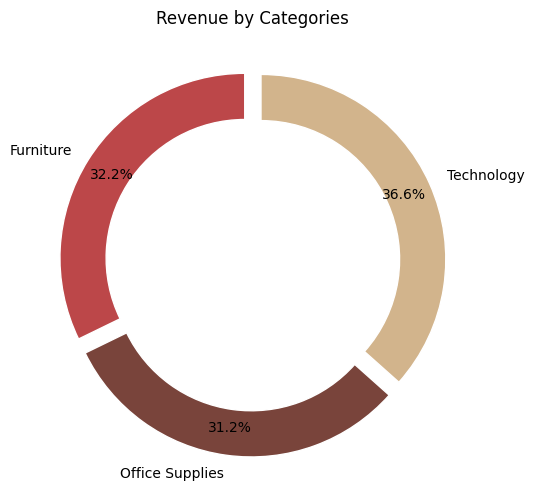

In [ ]:
plt.figure(figsize=(8,6))
plt.pie(cate_rev, labels=cate_rev.index,autopct ='%1.1f%%',
        colors = ['#bc4749', '#79443B', '#D2B48C'],
        explode= (0.05, 0.05, 0.05), pctdistance=0.85,startangle=90,
        wedgeprops=dict(width=.25, edgecolor='w'),radius=1)
plt.title('Revenue by Categories');

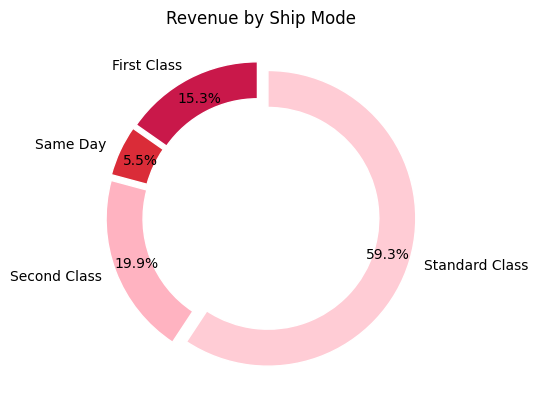

In [ ]:
ship_rev = df.groupby('Ship Mode')['Sales'].sum()
plt.pie(ship_rev, labels=ship_rev.index,autopct = '%1.1f%%',
        colors = ['#c9184a','#da2c38','#ffb3c1','#ffccd5'],
        explode= (0.05, 0.05, 0.05,0.05), pctdistance=0.85,
        wedgeprops=dict(width=.25, edgecolor='w'),radius=1,startangle=90)
plt.title('Revenue by Ship Mode');

In [ ]:
df['ship_year'] = pd.DatetimeIndex(df['Ship Date']).year
df['ship_year'].sample(9)


,ship_year
7496,2018
4937,2015
1676,2017
8996,2018
1370,2016
9234,2017
4188,2018
3717,2017
5348,2016


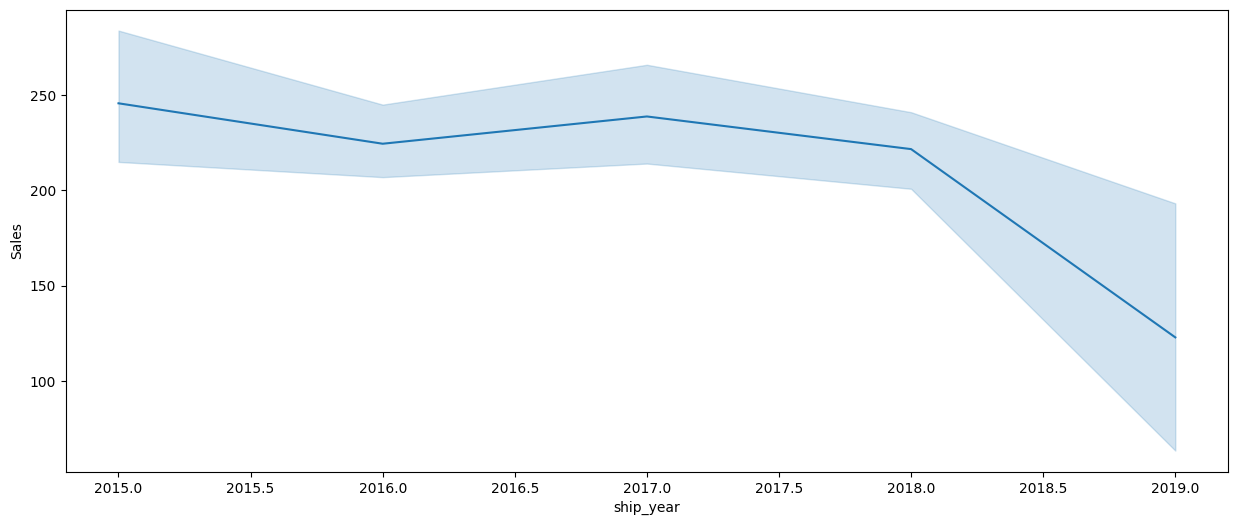

In [ ]:
plt.figure(figsize=(15,6))
sns.lineplot(data = df, x = 'ship_year', y = 'Sales',markers='o');
plt.show()